# Imports

In [1]:
! pip install pycocotools

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import copy
import os
import torch
from torch.utils.data import Dataset
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms.functional as tf
from torchvision.models.detection.ssd import SSDHead,det_utils
from torchvision.models.detection import ssd300_vgg16,SSD300_VGG16_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pycocotools
import torchmetrics
from torchmetrics.detection import MeanAveragePrecision

%matplotlib inline
sns.set_style("dark")

# Configuration

In [ ]:
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd()

images_dir = PROJECT_ROOT / "train" / "images"
labels_dir = PROJECT_ROOT / "train" / "labels"

classes = ["background", "Auto", "Bus", "Car", "LCV", "Motorcycle", "Truck", "Tractor", "Multi-Axle"]

num_classes = 9
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 4
epochs = 50
learning_rate = 3e-5

model_weights_file = "model.pth"

threshold = 0.3
iou_threshold = 0.8


# Imports

In [ ]:
! pip install pycocotools

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import copy
import os
import torch
from torch.utils.data import Dataset
from torch.utils.data import Subset
from torch.utils.data import DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms.functional as tf
from torchvision.models.detection.ssd import SSDHead,det_utils
from torchvision.models.detection import ssd300_vgg16,SSD300_VGG16_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pycocotools
import torchmetrics
from torchmetrics.detection import MeanAveragePrecision

%matplotlib inline
sns.set_style("dark")

# Configuration

In [ ]:
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd()

images_dir = PROJECT_ROOT / "train" / "images"
labels_dir = PROJECT_ROOT / "train" / "labels"

classes = ["background", "Auto", "Bus", "Car", "LCV", "Motorcycle", "Truck", "Tractor", "Multi-Axle"]

num_classes = 9
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 4
epochs = 50
learning_rate = 3e-5

model_weights_file = "model.pth"

threshold = 0.3
iou_threshold = 0.8


# Data Augmentation

In [9]:
train_transform=A.Compose([A.HorizontalFlip(),
                           A.ShiftScaleRotate(rotate_limit=15,value=0,
                                              border_mode=cv2.BORDER_CONSTANT),
                           A.CLAHE(),
                           A.GaussNoise()],
                          bbox_params=A.BboxParams(format="pascal_voc",min_visibility=0.7,
                                                   label_fields=["labels"]))

# Custom Dataset

In [10]:
class Vehicle(Dataset):
    def __init__(self,imgs_dir,annot_dir,transform=None):
        super().__init__()
        self.imgs_dir=imgs_dir
        self.labels_dir=annot_dir
        self.imgs_list=sorted([img_name for img_name in os.listdir(self.imgs_dir)
                               if img_name.endswith(".jpg")])
        self.transform=transform
        
    def __len__(self):
        return len(self.imgs_list)
    
    def __getitem__(self,idx):
        img_name=self.imgs_list[idx]
        img_path=os.path.join(self.imgs_dir,img_name)
        img=Image.open(img_path)
        w,h=img.size
        img=np.asarray(img)
        
        try:
            annot_name=img_name[:-4]+".txt"
            annot_path=os.path.join(self.labels_dir,annot_name)
            annot_data=pd.read_csv(annot_path,delimiter=" ",header=None).values
            labels=annot_data[:,0]
            labels=labels+1
            boxes=annot_data[:,1:5]
            
            xmin=((boxes[:,0]-boxes[:,2]/2)*w)[:,None]
            ymin=((boxes[:,1]-boxes[:,3]/2)*h)[:,None]
            xmax=((boxes[:,0]+boxes[:,2]/2)*w)[:,None]
            ymax=((boxes[:,1]+boxes[:,3]/2)*h)[:,None]
            boxes=np.concatenate((xmin,ymin,xmax,ymax),axis=1)
            
            if self.transform is not None:
                transformed=self.transform(image=img,bboxes=boxes,labels=labels)
                img=transformed["image"]
                boxes=transformed["bboxes"]
                labels=transformed["labels"]
                
            if len(np.array(boxes).shape)!=2 or np.array(boxes).shape[-1]!=4:
                boxes=[[0.0,0.0,1.0,1.0]]
                labels=[0]
        
        except:
            boxes=[[0.0,0.0,1.0,1.0]]
            labels=[0]
            
        img=img/255
        img=tf.to_tensor(img)
        img=img.to(dtype=torch.float32)
        target={}
        target["boxes"]=torch.tensor(boxes,dtype=torch.float32)
        target["labels"]=torch.tensor(labels,dtype=torch.int64)
        target["id"]=torch.tensor(idx)
            
        return img,target

In [11]:
train_ds=Vehicle(images_dir,labels_dir,train_transform)
val_ds=Vehicle(images_dir,labels_dir)

# Data Visualization

In [ ]:
def show_bbox(img, target, axis, color=(0,255,0)):
    img = np.transpose(img.cpu().numpy(), (1,2,0))
    img = (img * 255).astype(np.uint8)

    boxes = target["boxes"].cpu().numpy().astype("int")
    labels = target["labels"].cpu().numpy()

    img = img.copy()

    for i, box in enumerate(boxes):
        idx = int(labels[i])
        text = classes[idx]

        cv2.rectangle(img, (box[0],box[1]), (box[2],box[3]), color, 2)
        y = box[1]-10 if box[1]-10 > 10 else box[1]+10

        cv2.putText(img, text, (box[0],y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    axis.imshow(img)
    axis.axis("off")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB dat

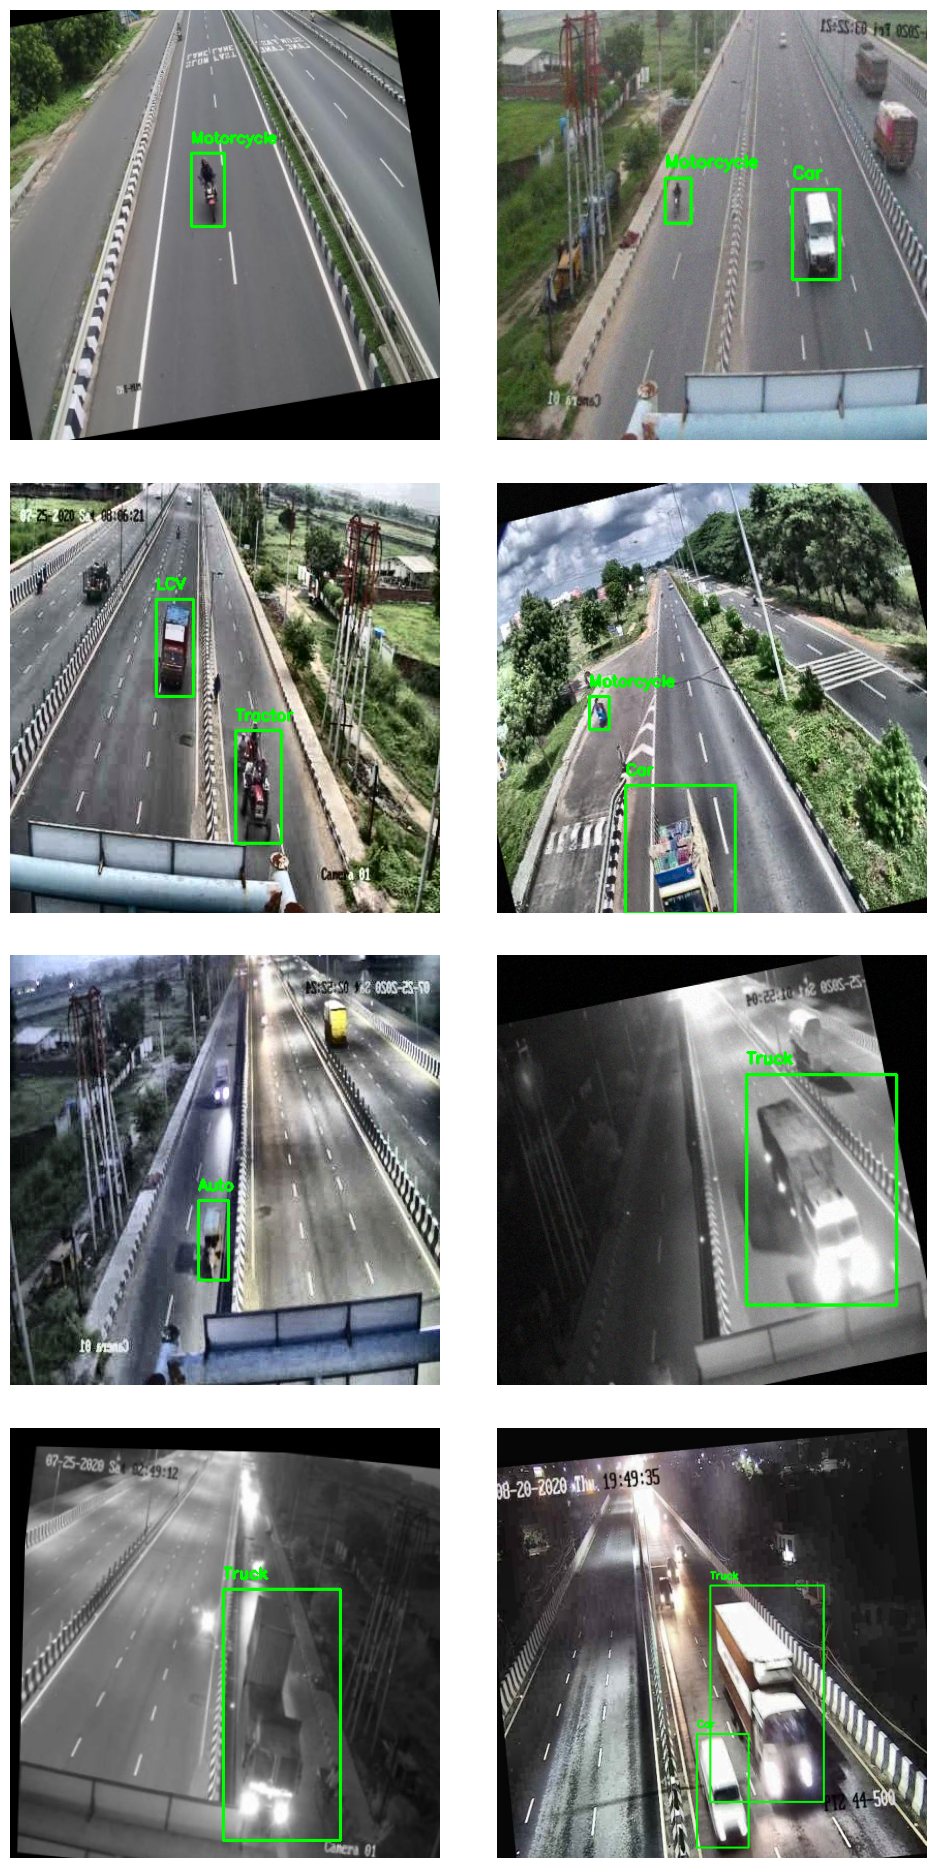

In [ ]:
fig, axes = plt.subplots(4,2,figsize=(12,24))
plt.subplots_adjust(wspace=0.1,hspace=0.1)
ax = axes.flatten()

idxs = np.random.choice(range(len(train_ds)), 8)

for i, idx in enumerate(idxs):
    img, target = train_ds[idx]
    show_bbox(img, target, axis=ax[i])

plt.savefig("sample_boxes.png")
plt.show()


# DataLoader

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=os.cpu_count(),
    collate_fn=collate_fn,
    pin_memory=True if device == "cuda" else False
)

val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=os.cpu_count(),
    collate_fn=collate_fn,
    pin_memory=True if device == "cuda" else False
)


# Model

In [ ]:
from torchvision.models.detection.ssd import SSDHead, det_utils

model = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)

in_channels = det_utils.retrieve_out_channels(
    model.backbone,
    (300,300)
)

num_anchors = model.anchor_generator.num_anchors_per_location()

model.head = SSDHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model.to(device)


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [ ]:
for params in model.backbone.features.parameters():
    params.requires_grad = False

parameters = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.Adam(parameters, lr=learning_rate)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=7,
    threshold=0.0001
)


# Training

In [ ]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


In [ ]:
loss_history = {
    "training_loss": [],
    "validation_loss": []
}

train_len = len(train_dl.dataset)
val_len   = len(val_dl.dataset)

best_validation_loss = float("inf")
best_weights = copy.deepcopy(model.state_dict())


'\nloss_history={"training_loss":[],\n              "validation_loss":[]}\n\ntrain_len=len(train_dl.dataset)\nval_len=len(val_dl.dataset)\n\nbest_validation_loss=np.inf\nbest_weights=copy.deepcopy(model.state_dict())\n\nfor epoch in range(epochs):\n    \n    training_loss=0.0\n    validation_loss=0.0\n    \n    current_lr=get_lr(optimizer)\n    \n    #During training, the model expects both the input tensors, as well as a targets \n    model.train()\n    for imgs,targets in train_dl:\n        imgs=[img.to(device) for img in imgs]\n        targets=[{k:v.to(device) for (k,v) in d.items()} for d in targets]\n        \n        loss_dict=model(imgs,targets)\n        losses=sum(loss for loss in loss_dict.values())\n        training_loss+=losses.item()\n        \n        optimizer.zero_grad()\n        losses.backward()\n        optimizer.step()\n        \n    with torch.no_grad():\n        for imgs,targets in val_dl:\n            imgs=[img.to(device) for img in imgs]\n            targets=[{k:

In [ ]:
for epoch in range(epochs):

    training_loss = 0.0
    validation_loss = 0.0

    current_lr = get_lr(optimizer)

    # -------- TRAINING --------
    model.train()
    for imgs, targets in train_dl:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        training_loss += losses.item()

    # -------- VALIDATION --------
    model.eval()
    with torch.no_grad():
        for imgs, targets in val_dl:

            imgs = [img.to(device) for img in imgs]
            targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            losses = sum(loss for loss in loss_dict.values())

            validation_loss += losses.item()

    # -------- SCHEDULER --------
    lr_scheduler.step(validation_loss / val_len)

    # -------- BEST MODEL --------
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_weights = copy.deepcopy(model.state_dict())
        print("Updating Best Model Weights")

    # -------- LOGGING --------
    loss_history["training_loss"].append(training_loss / train_len)
    loss_history["validation_loss"].append(validation_loss / val_len)

    print(f"\nEpoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {training_loss/train_len:.4f}")
    print(f"Val Loss  : {validation_loss/val_len:.4f}")
    print("-"*50)


'\nsns.lineplot(x=range(epochs),y=loss_history["training_loss"],label="Train Losses");\nsns.lineplot(x=range(epochs),y=loss_history["validation_loss"],label="Validation Losses");\nplt.title("Training Validation Datasets Losses Plot");\nplt.legend();'

In [ ]:
torch.save(best_weights, model_weights_file)
print("Best model saved successfully.")


In [ ]:
sns.lineplot(x=range(epochs), y=loss_history["training_loss"], label="Train Loss")
sns.lineplot(x=range(epochs), y=loss_history["validation_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


![](https://www.kaggleusercontent.com/kf/139619681/eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4Q0JDLUhTMjU2In0..hSM1_rdB3YyfjvF8TOuXjg.VXAER3M_d1j4hed-WgksbH1rje3QynSbH9DZzvylLj0rWugtSO-_qKxzIZLCdIG0-exlMbbFtOUQP0fWYEFueX6yWy3ZtLXQWPUthUjRdCK6nYS6L580-_t9u_cZfGObMaDr7XkHBGyyVuhwb1trlVf3c6hb9H5sYiXr2yG0Yg7GSB3_wz7ED5zX9r4UvmPOVZ8QJKX8kpl8RXUjz1pe3lyllc8lIHRnVRhcGLR0KPi1DaGHMehvYUJqJBYOFX_aOy2BGDzly1jZCifpPaUN4TIQTllRFEMxYebmIzBkOBTXI9v2KinmPJHFkUSJVWxajc2zbGjsUpqwi-yvfhxtG0hN1kpVZ7G6kA9m1D_-yEMxhUCnTRPCIYaORnUPBXUBKYZzD4SXVw2FepEZq_decqAmG2QuV5DNGNqUL3viNSkpSdL2CeGcEBU3kZKXcD9Z1MFPeQmUhm0G6_t-eSPUQqSIShnOt8xapv9yLnpjPLdgyQWjS7UuAh29bgcoMZegrh5h-sbUt-vpwlpSHZhNfhHXUUuLaebccmBxkv1biwszlivZ4ML9l6oxqjd2DljcgLra2M8m9evn0dFoOUJH485PX8LCLz-l9bMXro1i0WJbg4NmfaJRLFvje5UAgTeqxkDadJka_pHqZxTYKCfW0Z6il_bTslB5wG032_8M4NmPPNYDgm7DqmMwv6og4rSV.KTv-uTVzoswmqlORcoG-eg/3.png)

# Evaluation

In [ ]:
model_learned_weights = "model.pth"

model = ssd300_vgg16(weights=None, weights_backbone=None)

in_channels = det_utils.retrieve_out_channels(model.backbone, (300,300))
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head = SSDHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model.load_state_dict(torch.load(model_learned_weights, map_location=device))
model.to(device)


In [ ]:
def preprocess_bbox(prediction):

    processed_bbox = {}

    boxes  = prediction["boxes"][prediction["scores"] >= threshold]
    scores = prediction["scores"][prediction["scores"] >= threshold]
    labels = prediction["labels"][prediction["scores"] >= threshold]

    nms = torchvision.ops.nms(boxes, scores, iou_threshold=iou_threshold)

    processed_bbox["boxes"]  = boxes[nms]
    processed_bbox["scores"] = scores[nms]
    processed_bbox["labels"] = labels[nms]

    return processed_bbox


In [ ]:
metric = MeanAveragePrecision(
    box_format="xyxy",
    class_metrics=True
)

metric.to(device)

model.eval()
with torch.no_grad():
    for imgs, targets in val_dl:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        predictions = model(imgs)

        results = []
        for prediction in predictions:
            results.append(preprocess_bbox(prediction))

        metric.update(results, targets)

results = metric.compute()


In [ ]:
mean_ap = results["map"].item()
mean_ap_50 = results["map_50"].item()
mean_ap_75 = results["map_75"].item()

print(f"Mean Average Precision[0.5:0.95:0.05] : {mean_ap:.4f}")
print(f"Mean Average Precision @ 0.5          : {mean_ap_50:.4f}")
print(f"Mean Average Precision @ 0.75         : {mean_ap_75:.4f}")


In [ ]:
if len(results["map_per_class"]) == len(classes):
    map_per_class = results["map_per_class"][1:].tolist()
    mar_100_per_class = results["mar_100_per_class"][1:].tolist()
    obj_cls = classes[1:]
else:
    map_per_class = results["map_per_class"].tolist()
    mar_100_per_class = results["mar_100_per_class"].tolist()
    obj_cls = classes[1:]

data = list(zip(map_per_class, mar_100_per_class))
columns = ["Mean_Avg_Precision", "Mean_Avg_Recall"]

cls_map = pd.DataFrame(data, columns=columns, index=obj_cls)
cls_map.style.background_gradient(subset=columns, cmap="YlOrRd", high=0.75)


# Inference

In [ ]:
fig, axes = plt.subplots(4,2,figsize=(8,16))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

imgs, targets = next(iter(val_dl))

model.eval()
with torch.no_grad():
    output = model([img.to(device) for img in imgs])

for i in range(len(imgs)):
    img = imgs[i]
    prediction = output[i]

    # Ground Truth
    show_bbox(img, targets[i], axes[i,0], color=(0,255,0))

    # Prediction
    predict = preprocess_bbox(prediction)
    show_bbox(img, predict, axes[i,1], color=(255,0,0))

plt.savefig("inference_results.png")
plt.show()


# Data Augmentation

In [ ]:
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            rotate_limit=15,
            value=0,
            border_mode=cv2.BORDER_CONSTANT
        ),
        A.CLAHE(),
        A.GaussNoise(),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        min_visibility=0.7,
        label_fields=["labels"]
    )
)


# Custom Dataset

In [ ]:
class Vehicle(Dataset):

    def __init__(self, imgs_dir, annot_dir, transform=None):
        self.imgs_dir = imgs_dir
        self.labels_dir = annot_dir
        self.imgs_list = sorted([
            f for f in os.listdir(imgs_dir)
            if f.endswith(".jpg")
        ])
        self.transform = transform

    def __len__(self):
        return len(self.imgs_list)

    def __getitem__(self, idx):

        img_name = self.imgs_list[idx]
        img_path = os.path.join(self.imgs_dir, img_name)

        img = Image.open(img_path)
        w, h = img.size
        img = np.array(img)

        try:
            annot_path = os.path.join(
                self.labels_dir,
                img_name.replace(".jpg", ".txt")
            )

            annot = pd.read_csv(annot_path, sep=" ", header=None).values
            labels = annot[:,0] + 1
            boxes  = annot[:,1:5]

            xmin = (boxes[:,0] - boxes[:,2]/2) * w
            ymin = (boxes[:,1] - boxes[:,3]/2) * h
            xmax = (boxes[:,0] + boxes[:,2]/2) * w
            ymax = (boxes[:,1] + boxes[:,3]/2) * h

            boxes = np.stack([xmin,ymin,xmax,ymax], axis=1)

            if self.transform:
                t = self.transform(image=img, bboxes=boxes, labels=labels)
                img = t["image"]
                boxes = t["bboxes"]
                labels = t["labels"]

        except:
            boxes = [[0,0,1,1]]
            labels = [0]
            img = ToTensorV2()(image=img)["image"]

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "id": torch.tensor(idx)
        }

        return img, target


In [ ]:
train_ds = Vehicle(images_dir, labels_dir, train_transform)
val_ds   = Vehicle(images_dir, labels_dir, train_transform)


In [ ]:
idxs = list(range(len(train_ds)))
np.random.shuffle(idxs)

train_idx = idxs[:int(0.8*len(idxs))]
val_idx   = idxs[int(0.8*len(idxs)):]

train_ds = Subset(train_ds, train_idx)
val_ds   = Subset(val_ds, val_idx)


# Data Visualization

In [ ]:
def show_bbox(img, target, axis, color=(0,255,0)):

    img = np.transpose(img.cpu().numpy(), (1,2,0))
    img = (img * 255).astype(np.uint8)

    boxes = target["boxes"].cpu().numpy().astype(int)
    labels = target["labels"].cpu().numpy()

    for i, box in enumerate(boxes):
        text = classes[int(labels[i])]
        cv2.rectangle(img, (box[0],box[1]), (box[2],box[3]), color, 2)
        y = box[1]-10 if box[1]-10 > 10 else box[1]+10
        cv2.putText(img, text, (box[0],y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    axis.imshow(img)
    axis.axis("off")


In [ ]:
fig, axes = plt.subplots(4,2,figsize=(12,24))
plt.subplots_adjust(wspace=0.1,hspace=0.1)
ax = axes.flatten()

idxs = np.random.choice(range(len(train_ds)), 8)

for i, idx in enumerate(idxs):
    img, target = train_ds[idx]
    show_bbox(img, target, axis=ax[i])

plt.savefig("train_samples.png")
plt.show()


# DataLoader

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=os.cpu_count(),
    collate_fn=collate_fn,
    pin_memory=True if device == "cuda" else False
)

val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=os.cpu_count(),
    collate_fn=collate_fn,
    pin_memory=True if device == "cuda" else False
)


# Model

In [ ]:
model = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)

in_channels = det_utils.retrieve_out_channels(
    model.backbone,
    (300,300)
)

num_anchors = model.anchor_generator.num_anchors_per_location()

model.head = SSDHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model.to(device)


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [ ]:
for params in model.backbone.features.parameters():
    params.requires_grad = False

parameters = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.Adam(parameters, lr=learning_rate)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=7,
    threshold=0.0001
)


# Training

In [ ]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


In [ ]:
"""
loss_history = {
    "training_loss": [],
    "validation_loss": []
}

train_len = len(train_dl.dataset)
val_len   = len(val_dl.dataset)

best_validation_loss = float("inf")
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(epochs):

    training_loss = 0.0
    validation_loss = 0.0

    current_lr = get_lr(optimizer)

    model.train()
    for imgs, targets in train_dl:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        training_loss += losses.item()

    model.eval()
    with torch.no_grad():
        for imgs, targets in val_dl:

            imgs = [img.to(device) for img in imgs]
            targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

            loss_dict = model(imgs, targets)
            losses = sum(loss for loss in loss_dict.values())

            validation_loss += losses.item()

    lr_scheduler.step(validation_loss / val_len)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_weights = copy.deepcopy(model.state_dict())
        print("Updating Best Model Weights")

    loss_history["training_loss"].append(training_loss / train_len)
    loss_history["validation_loss"].append(validation_loss / val_len)

    print(f"\nEpoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {training_loss/train_len:.4f}")
    print(f"Val Loss  : {validation_loss/val_len:.4f}")
    print("-"*50)

torch.save(best_weights, model_weights_file)
"""


'\nloss_history={"training_loss":[],\n              "validation_loss":[]}\n\ntrain_len=len(train_dl.dataset)\nval_len=len(val_dl.dataset)\n\nbest_validation_loss=np.inf\nbest_weights=copy.deepcopy(model.state_dict())\n\nfor epoch in range(epochs):\n    \n    training_loss=0.0\n    validation_loss=0.0\n    \n    current_lr=get_lr(optimizer)\n    \n    #During training, the model expects both the input tensors, as well as a targets \n    model.train()\n    for imgs,targets in train_dl:\n        imgs=[img.to(device) for img in imgs]\n        targets=[{k:v.to(device) for (k,v) in d.items()} for d in targets]\n        \n        loss_dict=model(imgs,targets)\n        losses=sum(loss for loss in loss_dict.values())\n        training_loss+=losses.item()\n        \n        optimizer.zero_grad()\n        losses.backward()\n        optimizer.step()\n        \n    with torch.no_grad():\n        for imgs,targets in val_dl:\n            imgs=[img.to(device) for img in imgs]\n            targets=[{k:

In [ ]:
"""
sns.lineplot(x=range(epochs), y=loss_history["training_loss"], label="Train Loss")
sns.lineplot(x=range(epochs), y=loss_history["validation_loss"], label="Validation Loss")

plt.title("Training Validation Datasets Losses Plot")
plt.legend()
plt.show()
"""


'\nsns.lineplot(x=range(epochs),y=loss_history["training_loss"],label="Train Losses");\nsns.lineplot(x=range(epochs),y=loss_history["validation_loss"],label="Validation Losses");\nplt.title("Training Validation Datasets Losses Plot");\nplt.legend();'

![](https://www.kaggleusercontent.com/kf/139619681/eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4Q0JDLUhTMjU2In0..hSM1_rdB3YyfjvF8TOuXjg.VXAER3M_d1j4hed-WgksbH1rje3QynSbH9DZzvylLj0rWugtSO-_qKxzIZLCdIG0-exlMbbFtOUQP0fWYEFueX6yWy3ZtLXQWPUthUjRdCK6nYS6L580-_t9u_cZfGObMaDr7XkHBGyyVuhwb1trlVf3c6hb9H5sYiXr2yG0Yg7GSB3_wz7ED5zX9r4UvmPOVZ8QJKX8kpl8RXUjz1pe3lyllc8lIHRnVRhcGLR0KPi1DaGHMehvYUJqJBYOFX_aOy2BGDzly1jZCifpPaUN4TIQTllRFEMxYebmIzBkOBTXI9v2KinmPJHFkUSJVWxajc2zbGjsUpqwi-yvfhxtG0hN1kpVZ7G6kA9m1D_-yEMxhUCnTRPCIYaORnUPBXUBKYZzD4SXVw2FepEZq_decqAmG2QuV5DNGNqUL3viNSkpSdL2CeGcEBU3kZKXcD9Z1MFPeQmUhm0G6_t-eSPUQqSIShnOt8xapv9yLnpjPLdgyQWjS7UuAh29bgcoMZegrh5h-sbUt-vpwlpSHZhNfhHXUUuLaebccmBxkv1biwszlivZ4ML9l6oxqjd2DljcgLra2M8m9evn0dFoOUJH485PX8LCLz-l9bMXro1i0WJbg4NmfaJRLFvje5UAgTeqxkDadJka_pHqZxTYKCfW0Z6il_bTslB5wG032_8M4NmPPNYDgm7DqmMwv6og4rSV.KTv-uTVzoswmqlORcoG-eg/3.png)

# Evaluation

In [ ]:
model_learned_weights = "model.pth"

model = ssd300_vgg16(weights=None, weights_backbone=None)

in_channels = det_utils.retrieve_out_channels(model.backbone, (300,300))
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head = SSDHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model.load_state_dict(torch.load(model_learned_weights, map_location=device))
model.to(device)


In [ ]:
def preprocess_bbox(prediction):

    processed_bbox = {}

    mask = prediction["scores"] >= threshold

    boxes  = prediction["boxes"][mask]
    scores = prediction["scores"][mask]
    labels = prediction["labels"][mask]

    keep = torchvision.ops.nms(boxes, scores, iou_threshold)

    processed_bbox["boxes"]  = boxes[keep]
    processed_bbox["scores"] = scores[keep]
    processed_bbox["labels"] = labels[keep]

    return processed_bbox


In [ ]:
metric = MeanAveragePrecision(
    box_format="xyxy",
    class_metrics=True
)

metric.to(device)

model.eval()
with torch.no_grad():
    for imgs, targets in val_dl:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        predictions = model(imgs)

        results = []
        for prediction in predictions:
            results.append(preprocess_bbox(prediction))

        metric.update(results, targets)

results = metric.compute()


In [ ]:
mean_ap = results["map"].item()
mean_ap_50 = results["map_50"].item()
mean_ap_75 = results["map_75"].item()

print(f"Mean Average Precision[0.5:0.95] : {mean_ap:.4f}")
print(f"Mean Average Precision @0.5      : {mean_ap_50:.4f}")
print(f"Mean Average Precision @0.75     : {mean_ap_75:.4f}")


Mean Average Precision[0.5:0.95:0.05] : 0.5164
Mean Average Precision @ 0.5          : 0.5699
Mean Average Precision @ 0.75         : 0.5684


In [ ]:
if len(results["map_per_class"]) == len(classes):
    map_per_class = results["map_per_class"][1:].tolist()
    mar_100_per_class = results["mar_100_per_class"][1:].tolist()
    obj_cls = classes[1:]
else:
    map_per_class = results["map_per_class"].tolist()
    mar_100_per_class = results["mar_100_per_class"].tolist()
    obj_cls = classes[1:]

data = list(zip(map_per_class, mar_100_per_class))
columns = ["Mean_Avg_Precision", "Mean_Avg_Recall"]

cls_map = pd.DataFrame(data, columns=columns, index=obj_cls)
cls_map.style.background_gradient(subset=columns, cmap="YlOrRd", high=0.75)


# Inference

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(8,16))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

imgs, targets = next(iter(val_dl))

model.eval()
with torch.no_grad():
    output = model([img.to(device) for img in imgs])

for i in range(len(imgs)):
    img = imgs[i]
    prediction = output[i]

    # Ground Truth
    show_bbox(img, targets[i], axes[i,0], color=(0,255,0))

    # Prediction
    predict = preprocess_bbox(prediction)
    show_bbox(img, predict, axes[i,1], color=(255,0,0))

plt.savefig("inference_output.png")
plt.show()
